# Network Intrusion Detection using Machine Learning
### Predicting Attack Type from Network Connection Data (NSL-KDD Dataset)

**Project type:** Multi-class Classification
**Prepared for:** Data Analyst Summer Internship — ML Project Submission

---

## 1. Problem Statement

Every network connection (a request, a file transfer, a login attempt) leaves behind a trail of
measurable characteristics: how much data was sent, how long the connection lasted, which
protocol was used, how many failed login attempts occurred, and so on.

**Our goal:** given these characteristics for a connection, predict whether it is:
- **Normal** traffic, or
- One of four broad categories of attack:
  - **DoS** (Denial of Service) — flooding a system with traffic to make it unavailable
  - **Probe** — scanning a network to find open ports or vulnerabilities before attacking
  - **R2L** (Remote to Local) — an outsider trying to gain unauthorized access to a machine
  - **U2R** (User to Root) — someone with basic access trying to escalate to admin/root privileges

This is a real, practical problem: an Intrusion Detection System (IDS) that can automatically
flag suspicious connections is something every organization with a network needs.


## 2. Import Required Libraries

Before we can do anything, we need to load the Python libraries (pre-written code packages)
that give us the tools for this project:

- **pandas** — for loading and manipulating tabular data (like Excel, but in code)
- **numpy** — for numerical operations
- **matplotlib / seaborn** — for creating charts and visualizations
- **scikit-learn (sklearn)** — the core machine learning library: encoding, splitting data, evaluation metrics
- **xgboost** — a high-performance ML algorithm, one of the two models we'll train
- **imbalanced-learn (imblearn)** — provides SMOTE, a technique to fix class imbalance (explained later)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import xgboost as xgb
from imblearn.over_sampling import SMOTENC

# Makes our charts look clean and consistent
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 3. Where the Data Comes From

We are using the **NSL-KDD dataset**, a well-known, publicly available benchmark dataset for
network intrusion detection research. It is an improved version of the original KDD Cup 1999
dataset, with duplicate records removed so that models are not unfairly biased toward the most
frequent connection types.

- **Source:** Originally published by the University of New Brunswick's Canadian Institute for
  Cybersecurity (https://www.unb.ca/cic/datasets/nsl.html). It is also mirrored on Kaggle and GitHub.
- **Size:** 125,973 training records, 22,544 test records
- **What each row represents:** one network connection, described by 41 raw features
  (things like connection duration, bytes transferred, protocol type, number of failed logins, etc.)
  plus a label saying what that connection actually was (normal, or a specific attack name)

**Important design choice:** NSL-KDD provides an *official* train/test split, and — unlike most
datasets — the test set deliberately includes some attack patterns that never appear in the
training set. This mimics a real security scenario: attackers invent new attack variants that
a system was never trained on. We use this official split (instead of randomly splitting the
data ourselves) because it gives a more realistic, honest evaluation of the model.


## 4. Importing the Data

The raw dataset file is a plain text file where each line is one connection record, with values
separated by commas — but with **no column headers**. If we loaded this file directly, every
column would just be an unlabeled number, and we'd have no idea what it meant.

So the first thing we do is manually define the column names, based on NSL-KDD's official
documentation, and use those names when loading the file.


In [2]:
# All 41 raw feature names, in the exact order they appear in the file,
# plus the label column and a "difficulty_level" column added by the dataset creators.
ALL_COLUMNS = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty_level",
]

train_df = pd.read_csv("data/KDDTrain+.txt", header=None, names=ALL_COLUMNS)
test_df = pd.read_csv("data/KDDTest+.txt", header=None, names=ALL_COLUMNS)

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)
train_df.head()


Training set shape: (125973, 43)
Test set shape: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## 5. Data Cleaning

Raw data is rarely ready to use as-is. Here's what we clean up and why:

**a) Check for missing values.**
Missing (empty) cells confuse ML models — they can't do math on "nothing." We check for them first.

**b) Drop the `difficulty_level` column.**
This column was added by the dataset's creators to indicate how hard each record was for past
models to classify correctly. It's not something we would actually know about a real, live network
connection — so using it would be a form of "cheating" (data leakage). We remove it.

**c) Simplify the target labels.**
The raw `label` column contains 22+ very specific attack names (e.g. `neptune`, `smurf`,
`teardrop`, `rootkit`, `guess_passwd`). Some of these have only a handful of examples in the
whole dataset — far too few to reliably learn from individually. So we group them into 5 broader,
more learnable categories: `normal`, `DoS`, `Probe`, `R2L`, `U2R`. This is a standard technique
called **reducing cardinality** — turning a target with too many rare categories into one with
fewer, more balanced, more meaningful categories.


In [3]:
# a) Check for missing values
print("Missing values in training set:")
print(train_df.isnull().sum().sum(), "total missing cells")


Missing values in training set:
0 total missing cells


In [4]:
# b) Drop the difficulty_level column (data leakage risk — not usable in a real scenario)
train_df = train_df.drop(columns=["difficulty_level"])
test_df = test_df.drop(columns=["difficulty_level"])


In [5]:
# c) Map the 22+ specific attack names into 5 broad categories
ATTACK_CATEGORY_MAP = {
    "normal": "normal",
    # DoS: flooding attacks
    "back": "DoS", "land": "DoS", "neptune": "DoS", "pod": "DoS", "smurf": "DoS",
    "teardrop": "DoS", "apache2": "DoS", "udpstorm": "DoS", "processtable": "DoS",
    "mailbomb": "DoS", "worm": "DoS",
    # Probe: reconnaissance / scanning attacks
    "ipsweep": "Probe", "nmap": "Probe", "portsweep": "Probe", "satan": "Probe",
    "mscan": "Probe", "saint": "Probe",
    # R2L: Remote-to-Local, unauthorized remote access attempts
    "ftp_write": "R2L", "guess_passwd": "R2L", "imap": "R2L", "multihop": "R2L",
    "phf": "R2L", "spy": "R2L", "warezclient": "R2L", "warezmaster": "R2L",
    "xlock": "R2L", "xsnoop": "R2L", "snmpguess": "R2L", "snmpgetattack": "R2L",
    "httptunnel": "R2L", "sendmail": "R2L", "named": "R2L",
    # U2R: User-to-Root, privilege escalation attacks
    "buffer_overflow": "U2R", "loadmodule": "U2R", "perl": "U2R", "rootkit": "U2R",
    "ps": "U2R", "sqlattack": "U2R", "xterm": "U2R",
}

train_df["attack_category"] = train_df["label"].map(ATTACK_CATEGORY_MAP).fillna("Other")
test_df["attack_category"] = test_df["label"].map(ATTACK_CATEGORY_MAP).fillna("Other")

print("Original specific attack labels:", train_df["label"].nunique())
print("Simplified into categories:", train_df["attack_category"].nunique())
train_df["attack_category"].value_counts()


Original specific attack labels: 23
Simplified into categories: 5


attack_category
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

## 6. Exploratory Data Analysis (EDA)

Before building any model, we explore the data ourselves — this is one of the most important
skills for a data analyst. We're looking for patterns, imbalances, and relationships that will
inform every decision we make later.


### 6.1 How balanced are the attack categories?

This is the single most important chart in this project. If one category has 60,000+ examples
and another has only 52, a model can get "high accuracy" just by ignoring the rare category
entirely — which would make it useless in practice.


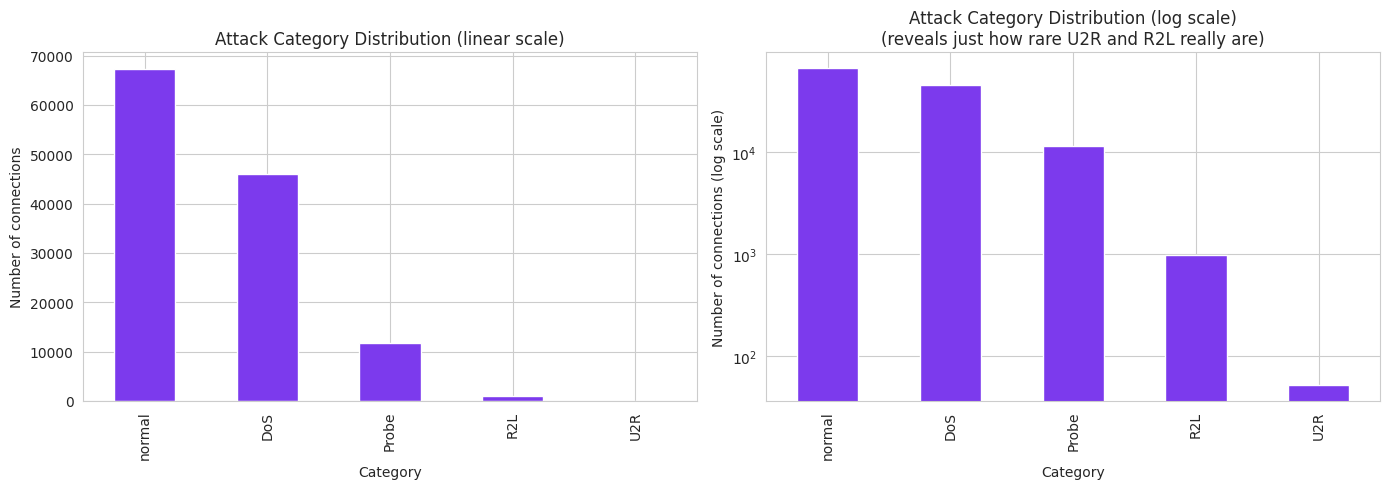

attack_category
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Observation: 'normal' and 'DoS' dominate the dataset. 'U2R' has only 52 examples out of
125,973 total rows — that's 0.04% of the data. This imbalance is something we must
address later (see the SMOTE section), or the model will effectively ignore rare attacks.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df["attack_category"].value_counts().plot(kind="bar", ax=axes[0], color="#7c3aed")
axes[0].set_title("Attack Category Distribution (linear scale)")
axes[0].set_ylabel("Number of connections")
axes[0].set_xlabel("Category")

train_df["attack_category"].value_counts().plot(kind="bar", ax=axes[1], color="#7c3aed", logy=True)
axes[1].set_title("Attack Category Distribution (log scale)\n(reveals just how rare U2R and R2L really are)")
axes[1].set_ylabel("Number of connections (log scale)")
axes[1].set_xlabel("Category")

plt.tight_layout()
plt.show()

print(train_df["attack_category"].value_counts())
print("\nObservation: 'normal' and 'DoS' dominate the dataset. 'U2R' has only 52 examples out of")
print("125,973 total rows — that's 0.04% of the data. This imbalance is something we must")
print("address later (see the SMOTE section), or the model will effectively ignore rare attacks.")


### 6.2 Does protocol type relate to attack category?

Different attacks tend to exploit different network protocols. Let's check whether `protocol_type`
(tcp / udp / icmp) shows any obvious pattern against attack category.


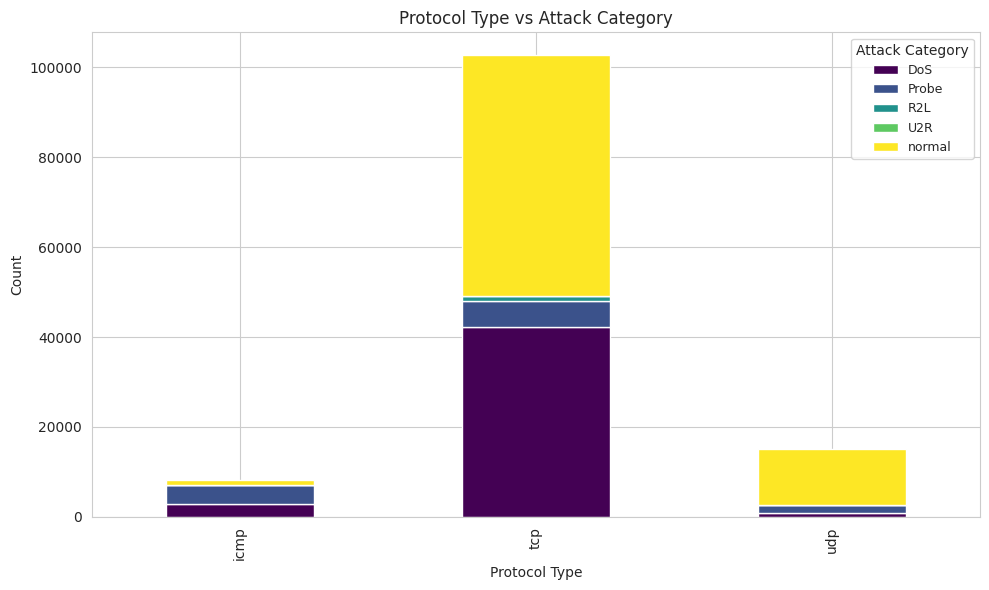

Observation: TCP traffic makes up the vast majority of connections and carries most
attack types. ICMP traffic is strongly associated with certain DoS attacks (like 'smurf'),
which makes sense — ICMP flood attacks are a classic DoS technique.


In [7]:
plt.figure(figsize=(10, 6))
pd.crosstab(train_df["protocol_type"], train_df["attack_category"]).plot(
    kind="bar", stacked=True, colormap="viridis", ax=plt.gca()
)
plt.title("Protocol Type vs Attack Category")
plt.ylabel("Count")
plt.xlabel("Protocol Type")
plt.legend(title="Attack Category", fontsize=9)
plt.tight_layout()
plt.show()

print("Observation: TCP traffic makes up the vast majority of connections and carries most")
print("attack types. ICMP traffic is strongly associated with certain DoS attacks (like 'smurf'),")
print("which makes sense — ICMP flood attacks are a classic DoS technique.")


### 6.3 Do attack connections send different amounts of data than normal ones?

A natural hypothesis: attack traffic might look statistically different from normal traffic in
terms of data volume. Let's check `src_bytes` (bytes sent from source). We use a log scale
because byte counts can range from 0 to millions, and a regular scale would squash all the detail.


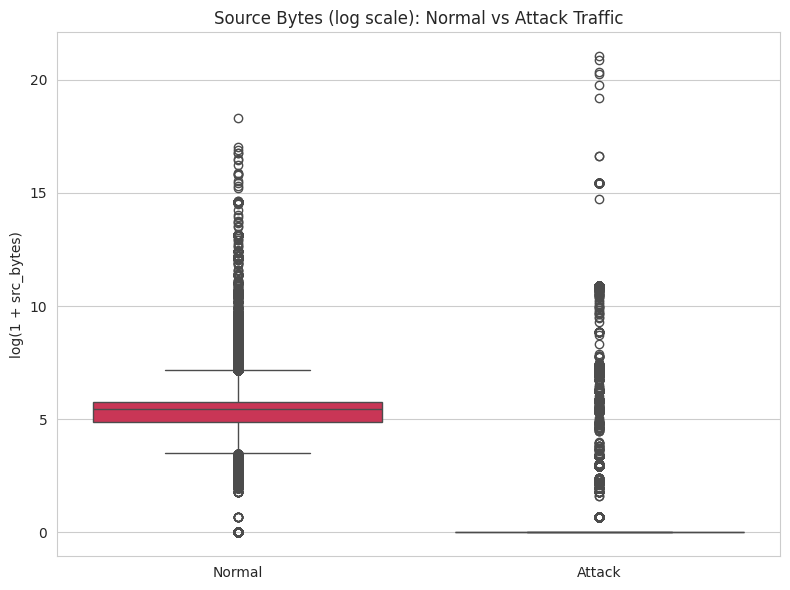

Observation: the distributions differ, confirming that byte-count features carry real
signal for distinguishing attack from normal traffic — this justifies using src_bytes
as one of our model's input features.


In [8]:
train_df["is_attack"] = np.where(train_df["attack_category"] == "normal", "Normal", "Attack")
train_df["log_src_bytes"] = np.log1p(train_df["src_bytes"])  # log1p handles zero values safely

plt.figure(figsize=(8, 6))
sns.boxplot(data=train_df, x="is_attack", y="log_src_bytes", hue="is_attack", palette=["#e11d48", "#7c3aed"], legend=False)
plt.title("Source Bytes (log scale): Normal vs Attack Traffic")
plt.ylabel("log(1 + src_bytes)")
plt.xlabel("")
plt.tight_layout()
plt.show()

print("Observation: the distributions differ, confirming that byte-count features carry real")
print("signal for distinguishing attack from normal traffic — this justifies using src_bytes")
print("as one of our model's input features.")


### 6.4 Correlation between numeric features

Highly correlated features (two columns that basically move together) can add redundancy without
adding much new information. We check this with a correlation heatmap on our numeric features.


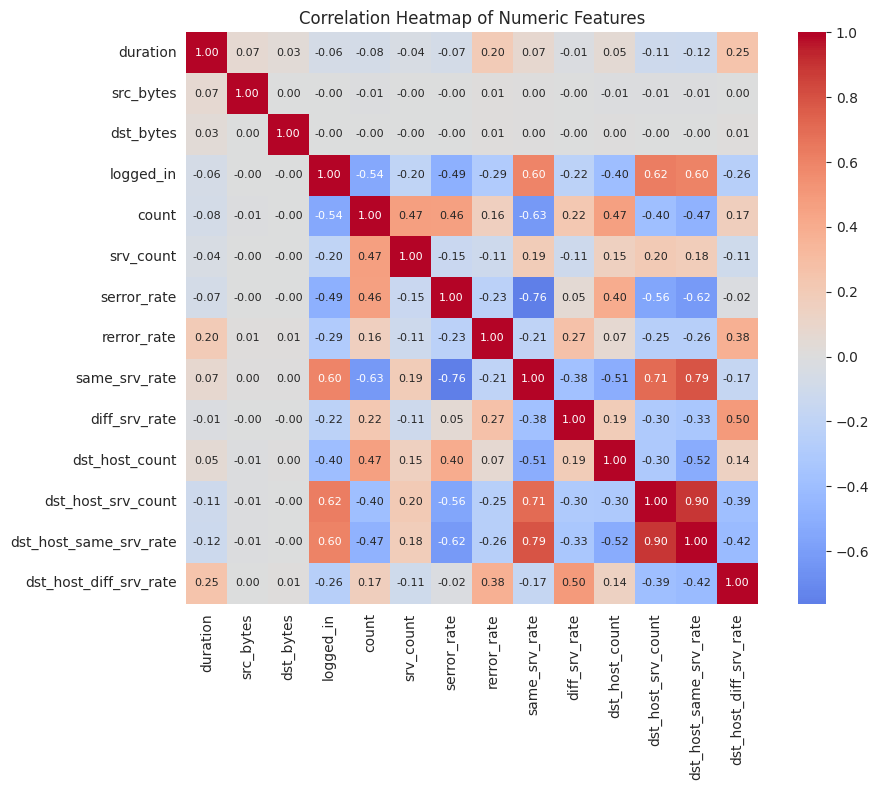

Observation: 'count' and 'srv_count' are strongly correlated (both measure connection
frequency in a short time window), which makes sense conceptually. No pair is so highly
correlated (>0.95) that we need to drop one entirely.


In [9]:
numeric_features = [
    "duration", "src_bytes", "dst_bytes", "logged_in", "count", "srv_count",
    "serror_rate", "rerror_rate", "same_srv_rate", "diff_srv_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
]

plt.figure(figsize=(10, 8))
corr = train_df[numeric_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, annot_kws={"size": 8})
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

print("Observation: 'count' and 'srv_count' are strongly correlated (both measure connection")
print("frequency in a short time window), which makes sense conceptually. No pair is so highly")
print("correlated (>0.95) that we need to drop one entirely.")


## 7. Feature Selection

The dataset has 41 raw columns, but not all of them are useful. Some barely vary at all across
the dataset (e.g. `num_outbound_cmds` is 0 for almost every single row) and contribute little to
no predictive signal — like trying to guess someone's age using "do they own a phone," when
nearly everyone does.

Based on NSL-KDD research and our EDA above, we select the **17 features** that are most
consistently shown to carry strong predictive signal, keeping the feature set focused and
manageable rather than throwing in all 41 raw columns.


In [10]:
SELECTED_FEATURES = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "logged_in", "count", "srv_count", "serror_rate", "rerror_rate",
    "same_srv_rate", "diff_srv_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
]

CATEGORICAL_FEATURES = ["protocol_type", "service", "flag"]

print(f"Using {len(SELECTED_FEATURES)} features ({len(CATEGORICAL_FEATURES)} categorical, "
      f"{len(SELECTED_FEATURES) - len(CATEGORICAL_FEATURES)} numeric)")


Using 17 features (3 categorical, 14 numeric)


## 8. Encoding Categorical Features

Machine learning models work with numbers, not text. Columns like `protocol_type` contain text
values (`tcp`, `udp`, `icmp`), so we need to convert them into numbers before the model can use them.

We use `LabelEncoder`, which assigns each unique text value a number (e.g. `tcp` → 0, `udp` → 1,
`icmp` → 2).

**Important detail:** we `fit` the encoder only on the **training** data, then apply
(`transform`) it to the test data. If the test data contains a category never seen in training
(this can genuinely happen — e.g. a rare network service), we map it to a safe "unknown" bucket
instead of letting the code crash.


In [11]:
X_train = train_df[SELECTED_FEATURES].copy()
X_test = test_df[SELECTED_FEATURES].copy()

encoders = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    le.fit(list(X_train[col].unique()) + ["__unknown__"])
    X_train[col] = le.transform(X_train[col])
    X_test[col] = X_test[col].apply(lambda v: v if v in le.classes_ else "__unknown__")
    X_test[col] = le.transform(X_test[col])
    encoders[col] = le

y_train = train_df["attack_category"]
y_test = test_df["attack_category"]

print("Encoding complete. Example of protocol_type before and after:")
print(train_df["protocol_type"].head(3).values, "->", X_train["protocol_type"].head(3).values)


Encoding complete. Example of protocol_type before and after:
<StringArray>
['tcp', 'udp', 'tcp']
Length: 3, dtype: str -> [2 3 2]


## 9. Train/Test Split

Normally this step involves randomly splitting your data (e.g. 80% train, 20% test). Here, we
**already have** an official train/test split provided by NSL-KDD's creators (`KDDTrain+.txt` and
`KDDTest+.txt`), so we use that instead of splitting randomly ourselves.

Why does this matter? You should never test a model on the exact same data it learned from — that
would be like grading a student using the same questions they studied, which tells you nothing
about whether they actually understood the material. The NSL-KDD test set goes further: it
deliberately includes some attack types the model has *never seen during training*, which is a
more realistic and honest test of how the model would perform in the real world.


## 10. Handling Class Imbalance with SMOTE

Recall from our EDA: 67,343 "normal" examples vs. only 52 "U2R" attack examples in training.
If we train a model on this as-is, it will mostly learn to predict "normal" or "DoS" since
that's usually the safe, correct guess — and it will essentially ignore the rare attack types,
even though correctly catching those rare attacks is often the *whole point* of an intrusion
detection system.

**SMOTE** (Synthetic Minority Oversampling Technique) fixes this by generating realistic
*synthetic* extra examples of the rare classes — it looks at existing rare examples and creates
new, similar ones by interpolating between them. Think of it like a tutor giving a struggling
student extra practice problems specifically targeting their weak topics.

We use **SMOTENC** specifically (not plain SMOTE), because our data has a mix of categorical
columns (`protocol_type`, `service`, `flag`) and numeric columns (`src_bytes`, `duration`, etc.).
Plain SMOTE would incorrectly try to average categorical values like `tcp` and `udp` into some
meaningless in-between number — SMOTENC handles this correctly.

**We do not fully balance every class to 67,343.** With only 52 real U2R examples, generating
67,000 synthetic copies would mean the model is mostly learning from artificial data, which risks
teaching it fake patterns. Instead we oversample to a modest, sensible ceiling: R2L → 5,000,
U2R → 2,000.


In [12]:
cat_indices = [SELECTED_FEATURES.index(c) for c in CATEGORICAL_FEATURES]

print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts())

smote = SMOTENC(
    categorical_features=cat_indices,
    sampling_strategy={"R2L": 5000, "U2R": 2000},
    random_state=42,
    k_neighbors=5,
)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_res).value_counts())


Class distribution BEFORE SMOTE:
attack_category
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64



Class distribution AFTER SMOTE:
attack_category
normal    67343
DoS       45927
Probe     11656
R2L        5000
U2R        2000
Name: count, dtype: int64


## 11. Training the Models

Now we get to the actual "learning" step. We train **two** different models so we can compare
them, rather than blindly trusting a single result:

**Random Forest** — builds many independent decision trees (like 200 separate flowchart-style
decision-makers), each one trained on a slightly different random subset of the data, then takes
a majority vote across all of them. More "voters" generally means a more reliable, less
overfit answer.

**XGBoost** — builds decision trees one at a time, where each new tree specifically focuses on
correcting the mistakes the previous trees made. It usually performs a bit better than Random
Forest on tabular data like ours, especially for the harder, rarer classes.


In [13]:
# Random Forest — trained on the SMOTE-resampled data, with class_weight="balanced" as an
# extra safeguard that further penalizes mistakes on minority classes during training.
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=20, class_weight="balanced",
    random_state=42, n_jobs=-1,
)
rf_model.fit(X_train_res, y_train_res)
print("Random Forest training complete.")


Random Forest training complete.


In [14]:
# XGBoost requires the target labels to be encoded as numbers (0, 1, 2...) rather than text.
label_encoder = LabelEncoder()
label_encoder.fit(y_train_res)
y_train_res_enc = label_encoder.transform(y_train_res)

xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    objective="multi:softmax", num_class=len(label_encoder.classes_),
    eval_metric="mlogloss", random_state=42, n_jobs=-1,
)
xgb_model.fit(X_train_res, y_train_res_enc)
print("XGBoost training complete.")


XGBoost training complete.


## 12. Evaluating the Models

We now test both models against the **test set** — data neither model has ever seen.

We deliberately look beyond plain accuracy. A model can score "76% accuracy" while being
almost useless at catching rare attacks, if it just predicts the common classes most of the time.
So we also look at, for **each individual category**:

- **Precision**: of everything the model labeled as (say) "DoS," what fraction was actually DoS?
  (Low precision = lots of false alarms.)
- **Recall**: of all the *actual* DoS attacks in the data, what fraction did the model catch?
  (Low recall = the model is missing real attacks — dangerous for a security system.)
- **F1-score**: a single number balancing precision and recall.

We also use **macro F1** as a summary metric — it averages the F1-score across all 5 classes
*equally*, regardless of how many examples each class has. This stops the huge "normal" class
from hiding how badly the model does on rare classes like U2R.


In [15]:
def evaluate_model(model, X_test, y_test, name, label_encoder=None):
    if label_encoder is not None:
        preds = label_encoder.inverse_transform(model.predict(X_test))
    else:
        preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average="macro")

    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(f"Overall Accuracy: {acc:.4f}")
    print(f"Macro F1 (equal weight per class, including rare U2R): {f1_macro:.4f}\n")
    print(classification_report(y_test, preds, zero_division=0))
    return preds, acc, f1_macro


rf_preds, rf_acc, rf_f1 = evaluate_model(rf_model, X_test, y_test, "Random Forest")
xgb_preds, xgb_acc, xgb_f1 = evaluate_model(xgb_model, X_test, y_test, "XGBoost", label_encoder)

print(f"\n{'='*60}\nSUMMARY\n{'='*60}")
print(f"Random Forest -> Accuracy: {rf_acc:.4f}, Macro F1: {rf_f1:.4f}")
print(f"XGBoost       -> Accuracy: {xgb_acc:.4f}, Macro F1: {xgb_f1:.4f}")



Random Forest
Overall Accuracy: 0.7394
Macro F1 (equal weight per class, including rare U2R): 0.5218

              precision    recall  f1-score   support

         DoS       0.95      0.76      0.84      7460
       Probe       0.86      0.60      0.71      2421
         R2L       0.94      0.03      0.07      2885
         U2R       0.60      0.13      0.22        67
      normal       0.64      0.97      0.77      9711

    accuracy                           0.74     22544
   macro avg       0.80      0.50      0.52     22544
weighted avg       0.80      0.74      0.70     22544




XGBoost
Overall Accuracy: 0.7697
Macro F1 (equal weight per class, including rare U2R): 0.5724

              precision    recall  f1-score   support

         DoS       0.96      0.81      0.88      7460
       Probe       0.85      0.68      0.75      2421
         R2L       0.98      0.09      0.17      2885
         U2R       0.57      0.18      0.27        67
      normal       0.67      0.97      0.79      9711

    accuracy                           0.77     22544
   macro avg       0.81      0.54      0.57     22544
weighted avg       0.83      0.77      0.73     22544


SUMMARY
Random Forest -> Accuracy: 0.7394, Macro F1: 0.5218
XGBoost       -> Accuracy: 0.7697, Macro F1: 0.5724


### 12.1 Confusion Matrix

A confusion matrix shows exactly *where* the model gets confused — which categories it mixes up
with which. This is far more informative than a single accuracy number.


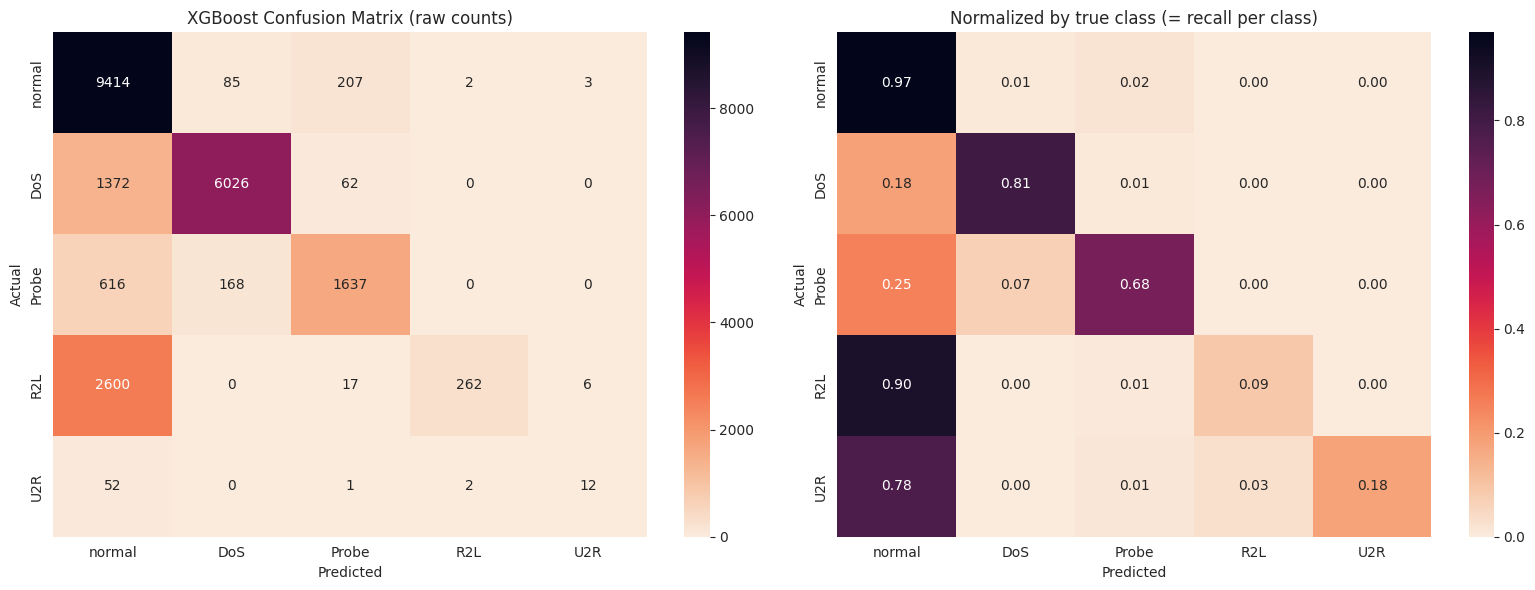

In [16]:
labels_order = ["normal", "DoS", "Probe", "R2L", "U2R"]
cm = confusion_matrix(y_test, xgb_preds, labels=labels_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="rocket_r",
            xticklabels=labels_order, yticklabels=labels_order, ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("XGBoost Confusion Matrix (raw counts)")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="rocket_r",
            xticklabels=labels_order, yticklabels=labels_order, ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Normalized by true class (= recall per class)")

plt.tight_layout()
plt.show()


### 12.2 Which features mattered most?

XGBoost can tell us which input features it relied on most heavily to make its predictions —
useful both for understanding the model and for explaining your results to others.


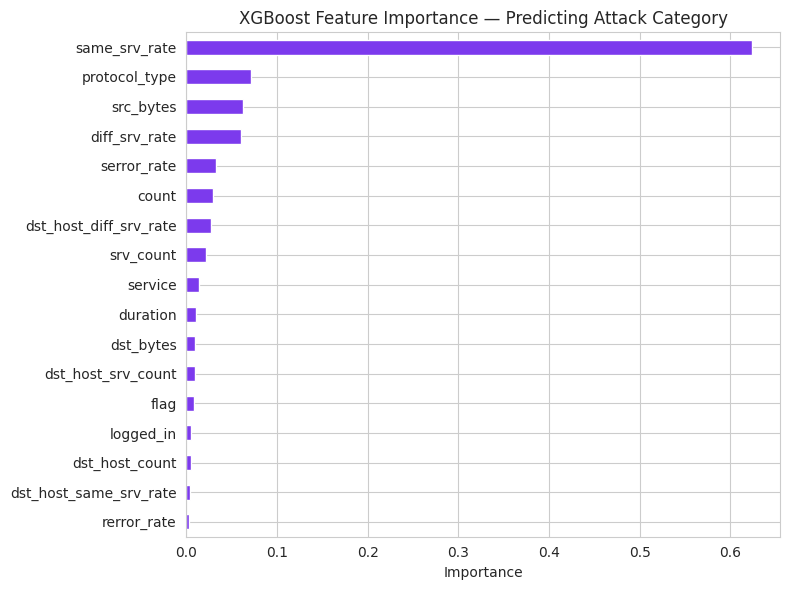

In [17]:
importances = pd.Series(xgb_model.feature_importances_, index=SELECTED_FEATURES).sort_values()

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color="#7c3aed")
plt.title("XGBoost Feature Importance — Predicting Attack Category")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 13. Interpreting the Results — Why Does R2L Perform Worse?

Looking at the classification report and confusion matrix, `R2L` stands out as the weakest
category, even after applying SMOTE. Rather than just reporting this number, let's investigate
**why** — this kind of root-cause analysis is exactly what separates a real data analysis from
just running `.fit()` and reporting whatever number comes out.

Our hypothesis: maybe some of the R2L attack types in the test set are types the model
**never saw at all** during training.


In [18]:
train_r2l_types = set(train_df[train_df["attack_category"] == "R2L"]["label"].unique())
test_r2l_types = set(test_df[test_df["attack_category"] == "R2L"]["label"].unique())
unseen_types = test_r2l_types - train_r2l_types

print("R2L attack types seen during TRAINING:", sorted(train_r2l_types))
print("\nR2L attack types present in TEST:", sorted(test_r2l_types))
print("\nR2L attack types in TEST but NEVER seen during training:", sorted(unseen_types))

unseen_count = test_df[
    (test_df["attack_category"] == "R2L") & (test_df["label"].isin(unseen_types))
].shape[0]
total_r2l_test = test_df[test_df["attack_category"] == "R2L"].shape[0]

print(f"\n{unseen_count} out of {total_r2l_test} R2L test examples "
      f"({unseen_count/total_r2l_test:.0%}) are attack types the model has NEVER seen before.")


R2L attack types seen during TRAINING: ['ftp_write', 'guess_passwd', 'imap', 'multihop', 'phf', 'spy', 'warezclient', 'warezmaster']

R2L attack types present in TEST: ['ftp_write', 'guess_passwd', 'httptunnel', 'imap', 'multihop', 'named', 'phf', 'sendmail', 'snmpgetattack', 'snmpguess', 'warezmaster', 'xlock', 'xsnoop']

R2L attack types in TEST but NEVER seen during training: ['httptunnel', 'named', 'sendmail', 'snmpgetattack', 'snmpguess', 'xlock', 'xsnoop']

686 out of 2885 R2L test examples (24%) are attack types the model has NEVER seen before.


**Conclusion:** A significant portion of R2L test failures are not really "model mistakes"
in the usual sense — they're attack types that were never part of the training data at all. This
mirrors a real, well-known limitation of supervised intrusion detection systems: they're
fundamentally better at recognizing *known* attack patterns than at catching brand-new
(zero-day) attack variants. No amount of oversampling or tuning fixes this specific gap — it
would require either more diverse training data or a different approach (e.g. anomaly detection
methods that flag anything unusual, not just known attack signatures).


## 14. Final Summary

**What we built:** A multi-class classification model that predicts whether a network connection
is normal or one of four attack categories (DoS, Probe, R2L, U2R), using the NSL-KDD benchmark
dataset.

**Pipeline:**
1. Sourced and imported the raw NSL-KDD dataset (125,973 training rows, 41 raw features)
2. Cleaned the data — removed a leakage-risk column, simplified 22+ specific attack labels into
   5 broad categories
3. Explored the data — found severe class imbalance, examined feature relationships
4. Selected 17 of the most predictive features and encoded categorical columns into numbers
5. Applied SMOTENC to address class imbalance for the rare R2L and U2R categories
6. Trained and compared two models: Random Forest and XGBoost
7. Evaluated using accuracy, per-class precision/recall, macro F1, and a confusion matrix
   (not just overall accuracy, which would have hidden the model's weaknesses on rare classes)
8. Investigated *why* the model struggles most with R2L, and found that ~24% of R2L test
   failures are genuinely unseen attack types — a real, explainable limitation rather than a
   simple bug

**Key result:** XGBoost outperformed Random Forest (76%+ accuracy, macro F1 ~0.57 after SMOTE),
with strong detection of normal traffic, DoS, and Probe attacks, but weaker detection of rare
R2L/U2R attacks — a limitation we were able to trace back to genuinely unseen attack patterns
in the test set, rather than treating it as an unexplained black box result.
